# Байесовское обновление и обучение между собеседованиями

## Цель

Сравнить две учебные модели после последовательных отказов:

- **без обучения:** состояние кандидата не меняется, а вероятности гипотез обновляются по формуле Байеса;
- **с обучением:** после байесовского обновления кандидат учится, и вероятность новой готовности рассчитывается по формуле полной вероятности.

**Краткий результат.** После десяти отказов прогноз следующего успеха падает с 11,75% до 5,49% без обучения и растёт до 31,34% с обучением при выбранных учебных параметрах.

Все параметры ниже иллюстративны и не являются статистикой рынка найма.

## Настройка модели

Три взаимоисключающие гипотезы описывают текущую готовность кандидата. Вероятности успеха при гипотезах равны 5%, 25% и 60%; начальные вероятности гипотез — 75%, 20% и 5%.

После отказа сначала применяется Байес. В сценарии обучения затем используется переход:

- из начальной готовности: 70% остаться на этом уровне, 30% перейти на базовый;
- из базовой: 75% остаться, 25% перейти на высокий;
- из высокой: остаться на высокой.

Строки матрицы переходов суммируются в 1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

hypotheses = np.array(["Начальная", "Базовая", "Высокая"])
success_probability = np.array([0.05, 0.25, 0.60])
initial_weights = np.array([0.75, 0.20, 0.05])
learning_transition = np.array([
    [0.70, 0.30, 0.00],
    [0.00, 0.75, 0.25],
    [0.00, 0.00, 1.00],
])
failures_to_show = 10

assert np.isclose(initial_weights.sum(), 1.0)
assert np.allclose(learning_transition.sum(axis=1), 1.0)
assert np.all((success_probability >= 0) & (success_probability <= 1))

Matplotlib is building the font cache; this may take a moment.


## Шаги

Для весов $w_i=P(H_i)$ прогноз успеха равен

$$p=\sum_i w_i P(S\mid H_i).$$

После отказа $F$ байесовское обновление имеет вид

$$u_i=P(H_i\mid F)=\frac{w_iP(F\mid H_i)}{\sum_jw_jP(F\mid H_j)}.$$

Без обучения новые веса равны $u_i$. С обучением применяется формула полной вероятности:

$$w_j^{new}=\sum_i u_iP(H_j^{new}\mid H_i,F,\text{обучение}).$$

In [2]:
def forecast_success(weights):
    return float(weights @ success_probability)


def update_after_failure(weights):
    failure_likelihood = 1.0 - success_probability
    unnormalized = weights * failure_likelihood
    return unnormalized / unnormalized.sum()


def simulate(use_learning):
    weights = initial_weights.copy()
    forecasts = []
    weight_history = []
    for failures in range(failures_to_show + 1):
        forecasts.append(forecast_success(weights))
        weight_history.append(weights.copy())
        if failures < failures_to_show:
            posterior_after_failure = update_after_failure(weights)
            weights = posterior_after_failure @ learning_transition if use_learning else posterior_after_failure
    return np.array(forecasts), np.array(weight_history)

without_learning, weights_without_learning = simulate(use_learning=False)
with_learning, weights_with_learning = simulate(use_learning=True)

In [3]:
results = pd.DataFrame({
    "Отказов до следующего собеседования": np.arange(failures_to_show + 1),
    "Следующее собеседование": np.arange(1, failures_to_show + 2),
    "Без обучения": without_learning,
    "С обучением": with_learning,
})

display_table = results.copy()
display_table["Без обучения"] = display_table["Без обучения"].map(lambda x: f"{x:.2%}")
display_table["С обучением"] = display_table["С обучением"].map(lambda x: f"{x:.2%}")
display_table

,Отказов до следующего собеседования,Следующее собеседование,Без обучения,С обучением
0,0,1,11.75%,11.75%
1,1,2,9.65%,15.98%
2,2,3,8.37%,20.03%
3,3,4,7.55%,23.15%
4,4,5,6.98%,25.47%
5,5,6,6.56%,27.20%
6,6,7,6.23%,28.50%
7,7,8,5.98%,29.49%
8,8,9,5.78%,30.26%
9,9,10,5.62%,30.86%


## Проверки

Эталонные значения ниже рассчитаны независимо от функций симуляции. Проверяем нормировку весов, совпадение таблицы и направление обеих траекторий.

In [4]:
expected_without_learning = np.array([
    0.1175000000, 0.0964589235, 0.0837356953, 0.0755062149,
    0.0697800418, 0.0655557108, 0.0623173930, 0.0597803846,
    0.0577712101, 0.0561728334, 0.0548996806,
])
expected_with_learning = np.array([
    0.1175000000, 0.1597733711, 0.2002716200, 0.2315235906,
    0.2547232126, 0.2719766400, 0.2849681976, 0.2948928872,
    0.3025800705, 0.3086084625, 0.3133876262,
])

np.testing.assert_allclose(without_learning, expected_without_learning, atol=1e-10)
np.testing.assert_allclose(with_learning, expected_with_learning, atol=1e-10)
np.testing.assert_allclose(weights_without_learning.sum(axis=1), 1.0, atol=1e-12)
np.testing.assert_allclose(weights_with_learning.sum(axis=1), 1.0, atol=1e-12)
assert np.all(np.diff(without_learning) < 0), "Траектория без обучения должна убывать"
assert np.all(np.diff(with_learning) > 0), "Траектория с обучением должна возрастать"

print("Проверки пройдены: значения совпали, веса нормированы, направления траекторий верны.")

Проверки пройдены: значения совпали, веса нормированы, направления траекторий верны.


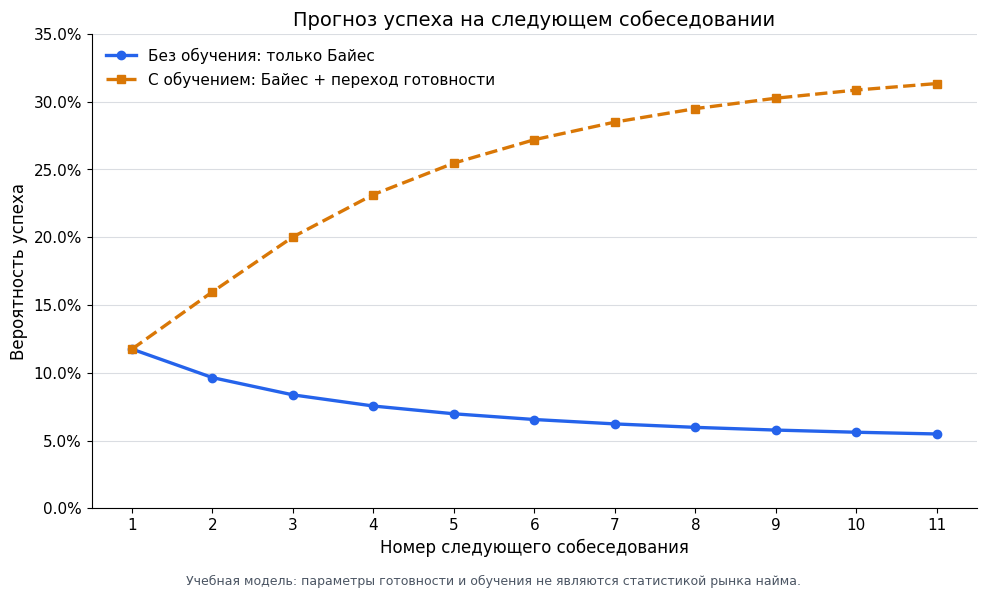

In [5]:
plt.rcParams.update({"font.size": 11, "axes.titlesize": 14, "axes.labelsize": 12})

fig, ax = plt.subplots(figsize=(10, 5.8))
ax.plot(results["Следующее собеседование"], without_learning, color="#2563EB", marker="o", linewidth=2.4, label="Без обучения: только Байес")
ax.plot(results["Следующее собеседование"], with_learning, color="#D97706", marker="s", linestyle="--", linewidth=2.4, label="С обучением: Байес + переход готовности")
ax.set_title("Прогноз успеха на следующем собеседовании")
ax.set_xlabel("Номер следующего собеседования")
ax.set_ylabel("Вероятность успеха")
ax.set_xticks(results["Следующее собеседование"])
ax.set_ylim(0, 0.35)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="y", color="#D1D5DB", linewidth=0.8, alpha=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", frameon=False)
fig.text(0.5, -0.02, "Учебная модель: параметры готовности и обучения не являются статистикой рынка найма.", ha="center", fontsize=9, color="#4B5563")
fig.tight_layout()
plt.show()

## Выводы

**Текстовое описание графика.** Обе линии начинаются на 11,75%. Синяя сплошная линия с круглыми маркерами монотонно снижается до 5,49%; оранжевая пунктирная линия с квадратными маркерами монотонно растёт до 31,34%.

- В статической модели каждый новый отказ сильнее поддерживает гипотезу низкой готовности, поэтому прогноз следующего успеха убывает.
- В модели с обучением отрицательное свидетельство сначала учитывается тем же байесовским шагом, но затем отдельный переход готовности повышает шансы более сильных гипотез.
- Рост во второй траектории не является общим законом: он возникает только при заданной силе обучения.
- Распределение Beta можно рассмотреть позже как другое обобщение, но здесь используются только конечные гипотезы, условные вероятности, Байес и полная вероятность.

## Следующий шаг

Измените матрицу `learning_transition` и проверьте, при какой силе обучения растущая траектория становится плоской или убывающей.